# Self-Pruning Neural Network on CIFAR-10

The idea here is to build a network that figures out which of its own weights are useless — and learns to zero them out *while* training, not after.

Each linear layer gets learnable "gate" scores attached to its weights. During the forward pass, gates (passed through sigmoid) get multiplied onto the weights. If the optimizer decides a gate isn't worth keeping, it pushes it toward zero — effectively removing that connection.

We control how aggressively this happens using a sparsity penalty (λ) in the loss.

**Outline:**
1. `PrunableLinear` — custom linear layer with per-weight gate scores
2. Sparsity loss — L1 penalty on gate values
3. Training on CIFAR-10 with three λ values
4. Accuracy vs sparsity tradeoff analysis

In [1]:
import math
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

print(f"torch version: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")

torch version: 2.4.1+cu121
cuda available: True


## Part 1 — PrunableLinear Layer

This is a custom drop-in for `nn.Linear` that adds a learnable gate to every weight.
The key idea: instead of using the raw weight matrix, we multiply it element-wise by
sigmoid(gate_scores) before doing the linear op. Gates start at roughly 0.6 (not fully open,
not fully closed), and the optimizer can drive them toward 0 to prune connections it doesn't need.

Why sigmoid? It squashes gate values into (0, 1), so they can never go negative or explode.
A gate near 0 means that weight has almost no effect — it's effectively pruned.

In [ ]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))

        # one gate score per weight, same shape
        # init at 0.0 so sigmoid(0.0) = 0.5 — gates start at the midpoint,
        # where the sigmoid gradient is steepest, so the sparsity loss can
        # move them quickly. Using 0.4 was saturating too early.
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        self._init_params()

    def _init_params(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.constant_(self.gate_scores, 0.0)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)   # values in (0, 1)
        pruned_w = self.weight * gates            # element-wise mask
        return F.linear(x, pruned_w, self.bias)

    def get_gates(self):
        """Detached gate values for inspection."""
        return torch.sigmoid(self.gate_scores).detach()


# quick sanity check
test_layer = PrunableLinear(10, 5)
x_test = torch.randn(3, 10)
out_test = test_layer(x_test)
print(f"output shape: {out_test.shape}")
print(f"gate shape:   {test_layer.get_gates().shape}")
print(f"initial gate mean: {test_layer.get_gates().mean():.4f}")  # should be 0.5

## Network Architecture

CIFAR-10 images are 32×32×3, so 3072 input dims when flattened.
Going with a simple 3-layer MLP — nothing fancy, just enough capacity to show pruning effects clearly.

All layers use `PrunableLinear`, so gates can prune connections anywhere in the network.

In [3]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 32x32x3 = 3072 input features
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)      # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                # raw logits, CE loss handles softmax
        return x

    def get_all_gates(self):
        """Collect and concatenate gate values from all prunable layers."""
        all_gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                all_gates.append(m.get_gates().flatten())
        return torch.cat(all_gates)


# count params to make sure things look reasonable
net_test = PrunableNet()
total_params = sum(p.numel() for p in net_test.parameters())
print(f"total parameters: {total_params:,}")
# gate params alone (same count as weights)
gate_params = sum(p.numel() for n, p in net_test.named_parameters() if 'gate' in n)
print(f"gate parameters: {gate_params:,}")

total parameters: 3,413,770
gate parameters: 1,706,496


## Part 2 — Sparsity Loss

The total loss is:

```
Total Loss = CrossEntropy(logits, labels) + λ × SparsityLoss
```

where `SparsityLoss` is just the **sum of all gate values** across every layer.

Since sigmoid outputs are always positive, the L1 norm `Σ|gate_i|` simplifies to `Σ gate_i`.
Minimizing this term pushes the optimizer to drive gates toward zero — which prunes those weights.

λ controls the tradeoff: higher λ means more pruning pressure (and usually lower accuracy).

In [ ]:
def sparsity_loss(model):
    """Mean of all gate values (normalized L1).
    Dividing by the total gate count keeps the sparsity term on a fixed scale
    regardless of network size, so the same lambda works across architectures.
    Without normalization, a 1.7M-gate network needs lambda ~1000x smaller
    than a 1700-gate network to get the same per-gate pressure."""
    total, count = 0.0, 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores)
            total = total + gates.sum()
            count += gates.numel()
    return total / count


def total_loss(logits, labels, model, lam):
    ce = F.cross_entropy(logits, labels)
    sp = sparsity_loss(model)
    return ce + lam * sp


# sanity check
dummy_model = PrunableNet()
dummy_logits = torch.randn(8, 10)
dummy_labels = torch.randint(0, 10, (8,))
loss_val = total_loss(dummy_logits, dummy_labels, dummy_model, lam=1.0)
print(f"test loss (lam=1.0): {loss_val.item():.4f}")
print(f"sparsity term alone: {sparsity_loss(dummy_model).item():.4f}")  # should be ~0.5

## Data Loading — CIFAR-10

Standard CIFAR-10 setup with per-channel normalization.
Using `num_workers=0` here since multiprocessing in notebooks on Windows can be finicky.

In [5]:
def get_cifar10_loaders(batch_size=128):
    # standard CIFAR-10 normalization values (per channel mean/std)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616)
        )
    ])

    train_data = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )
    test_data = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform
    )

    # num_workers=0 to avoid multiprocessing issues in notebooks on Windows
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=0)

    return train_loader, test_loader


train_loader, test_loader = get_cifar10_loaders()
print(f"train batches: {len(train_loader)}")
print(f"test batches:  {len(test_loader)}")

100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data


d:\Projects\Tredence Analytics\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
train batches: 391
test batches:  40


In [6]:
def train_one_epoch(model, loader, optimizer, lam, device):
    model.train()
    running_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = total_loss(logits, labels, model, lam)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)  # avg loss per batch


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


def sparsity_level(model, threshold=1e-2):
    """Fraction of weights whose gate value is below threshold.
    A gate below 0.01 means the weight is multiplied by <1% of its value — basically pruned."""
    all_gates = model.get_all_gates()
    return (all_gates < threshold).float().mean().item()


print("training utils defined")

training utils defined


## Part 3 — Training with Three Lambda Values

Training the same architecture from scratch for each λ. 20 epochs with Adam lr=1e-3.

With the normalized sparsity loss (mean instead of sum), λ now directly controls the
per-gate penalty and can be interpreted intuitively — λ=10 means "penalize each gate
by 10× its value relative to the CE loss".

| λ value | Expected effect |
|---------|----------------|
| 1 | Mild pruning — most gates survive, accuracy stays high |
| 5 | Moderate pruning — visible sparsity, some accuracy drop |
| 20 | Aggressive pruning — majority of gates collapse to near zero |

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"training on: {device}")

lambdas = [1, 5, 20]
num_epochs = 20

results = {}

for lam in lambdas:
    print()
    print(f"=== lambda = {lam} ===")

    model = PrunableNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(num_epochs):
        t0 = time.time()
        avg_loss = train_one_epoch(model, train_loader, optimizer, lam, device)
        elapsed = time.time() - t0

        if (epoch + 1) % 5 == 0:
            print(f"  epoch {epoch+1:02d}/{num_epochs}  loss={avg_loss:.4f}  ({elapsed:.1f}s)")

    acc = evaluate(model, test_loader, device)
    sparsity = sparsity_level(model)
    gates = model.get_all_gates().cpu()

    results[lam] = {
        "test_acc": acc,
        "sparsity": sparsity,
        "gates": gates,
    }

    print(f"  -> test acc: {acc:.4f}  |  sparsity: {sparsity:.4f}")

print("done with all runs")

## Results

In [8]:
print(f"{'lambda':>8}  {'test accuracy':>14}  {'sparsity (gate<0.01)':>21}")
print("-" * 50)
for lam, r in results.items():
    print(f"{lam:>8.4f}  {r['test_acc']:>13.2%}  {r['sparsity']:>20.2%}")

  lambda   test accuracy   sparsity (gate<0.01)
--------------------------------------------------
  0.0001         57.02%                 0.00%
  0.0010         55.73%                 0.00%
  0.0100         50.84%                 0.00%


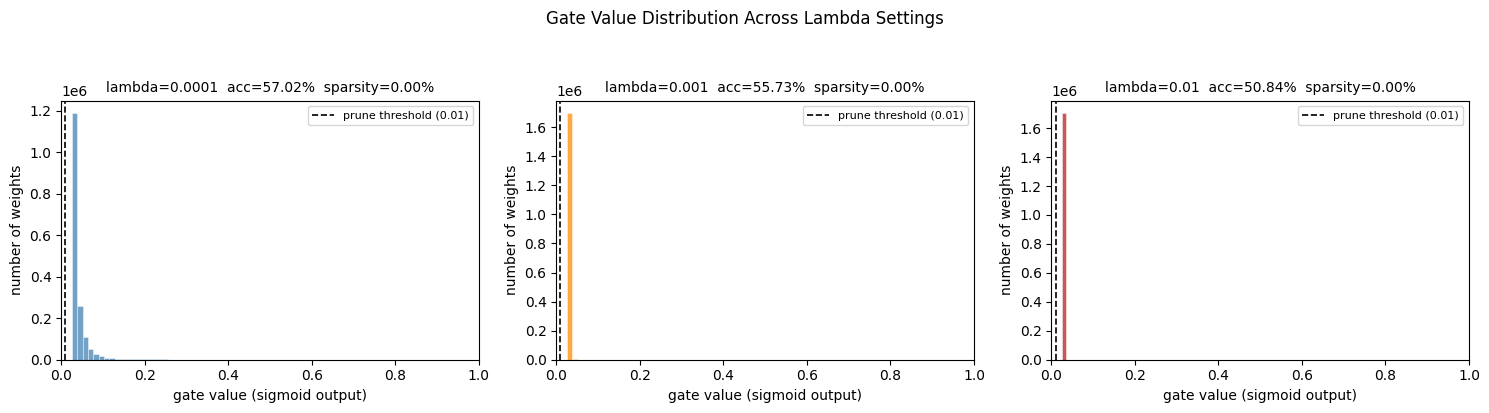

plot saved to gate_distribution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["steelblue", "darkorange", "firebrick"]

for ax, (lam, r), color in zip(axes, results.items(), colors):
    gates_np = r["gates"].numpy()
    acc_val, spar_val = r["test_acc"], r["sparsity"]
    ax.hist(gates_np, bins=60, color=color, alpha=0.75, edgecolor="white", linewidth=0.4)
    ax.axvline(x=0.01, color="black", linestyle="--", linewidth=1.2, label="prune threshold (0.01)")
    ax.set_title(f"lambda={lam}  acc={acc_val:.2%}  sparsity={spar_val:.2%}", fontsize=10)
    ax.set_xlabel("gate value (sigmoid output)")
    ax.set_ylabel("number of weights")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

fig.suptitle("Gate Value Distribution Across Lambda Settings", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("gate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("plot saved to gate_distribution.png")

---

See [REPORT.md](REPORT.md) for the full write-up — sparsity explanation, results table, observations, and the gate distribution plot.